In [21]:
import pandas as pd

# Eksplorasi struktur data

## LABEL: Sentimen hasil pelabelan manual (1: Positif, 0: Netral, -1: Negatif).

In [22]:
df = pd.read_excel('/content/data_ai.xlsx')
df.head()

,penulis,id_user,waktu,isi_tweet,label
0,nangisadalahprivilege,@nangisadalahprivilege,2026-02-15T04:16:42.000Z,info chatgpt prem dong ato perplexity prem yg murce #zonajajan #zonauang #mahasiswa,0.0
1,HasbiyalFurqon#IndonesiaGelap,@HasbiyalFurqon#IndonesiaGelap,2025-06-26T00:48:02.000Z,"Saya sempet iseng-isengan aja, kalo anggaran proyek MBG yang 71T itu dipindahkan untuk subsidi seluruh mahasiswa di Indonesia (data nya saya minta ChatGPT jadi mungkin kurang akurat) rata-rata sebenernya bisa dapet sekitar 7 jutaan setahun.",1.0
2,halig,@halig,2026-02-24T04:31:06.000Z,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua KLIK,0.0
3,Hudya,@Hudya,2025-05-31T08:05:16.000Z,Mahasiswa yang makin manja dengan ChatGPT bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan. So saya memutuskan bergabung menjadi youtuber edukasi pemrograman. Bedanya konten saya bener-bener akan ngomongin basicnya aja untuk level mahasiswa,-1.0
4,MinDos,@MinDos,2024-01-09T06:14:22.000Z,"Iseng nanya chatgpt... Mahasiswa kesmas bisa magang dimana saja? Jawabannya: Untuk mencari referensi tempat magang bagi mahasiswa Kesehatan Masyarakat, Anda dapat: 1. **Kampus dan Dosen**: Kampus tempat Anda kuliah dan dosen di bidang Kesehatan Masyarakat bisa memberikan",0.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   penulis    1140 non-null   object 
 1   id_user    1153 non-null   object 
 2   waktu      1153 non-null   object 
 3   isi_tweet  1153 non-null   object 
 4   label      1151 non-null   float64
dtypes: float64(1), object(4)
memory usage: 45.2+ KB


In [24]:
# Menghapus kolom yang tidak diperlukan
df = df.drop(columns=['waktu'])

In [25]:
df.head()

,penulis,id_user,isi_tweet,label
0,nangisadalahprivilege,@nangisadalahprivilege,info chatgpt prem dong ato perplexity prem yg murce #zonajajan #zonauang #mahasiswa,0.0
1,HasbiyalFurqon#IndonesiaGelap,@HasbiyalFurqon#IndonesiaGelap,"Saya sempet iseng-isengan aja, kalo anggaran proyek MBG yang 71T itu dipindahkan untuk subsidi seluruh mahasiswa di Indonesia (data nya saya minta ChatGPT jadi mungkin kurang akurat) rata-rata sebenernya bisa dapet sekitar 7 jutaan setahun.",1.0
2,halig,@halig,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua KLIK,0.0
3,Hudya,@Hudya,Mahasiswa yang makin manja dengan ChatGPT bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan. So saya memutuskan bergabung menjadi youtuber edukasi pemrograman. Bedanya konten saya bener-bener akan ngomongin basicnya aja untuk level mahasiswa,-1.0
4,MinDos,@MinDos,"Iseng nanya chatgpt... Mahasiswa kesmas bisa magang dimana saja? Jawabannya: Untuk mencari referensi tempat magang bagi mahasiswa Kesehatan Masyarakat, Anda dapat: 1. **Kampus dan Dosen**: Kampus tempat Anda kuliah dan dosen di bidang Kesehatan Masyarakat bisa memberikan",0.0


In [26]:
print(df['label'].unique())
print(df['label'].dtype)

[  0.   1.  -1. -11.  nan]
float64


In [27]:
df['label'] = df['label'].map({0.0: 0, 1.0: 1, -1.0: -1}).astype('Int64')

In [28]:
# Cek dan hapus baris dengan missing values pada label
print(f"Sebelum: {len(df)} baris")
print(f"Missing values di label: {df['label'].isna().sum()}")

# Drop baris dengan label NaN
df = df.dropna(subset=['label'])

# Ubah label dari float ke integer
df['label'] = df['label'].map({0.0: 0, 1.0: 1, -1.0: -1}).astype(int)

print(f"\nSesudah: {len(df)} baris")

Sebelum: 1153 baris
Missing values di label: 3

Sesudah: 1150 baris


In [29]:
len(df)

1150

In [30]:
# Konfigurasi pandas untuk menampilkan teks panjang tanpa terpotong
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print("Pandas display options configured")
print("\nMenampilkan data:")
df.head()

Pandas display options configured

Menampilkan data:


,penulis,id_user,isi_tweet,label
0,nangisadalahprivilege,@nangisadalahprivilege,info chatgpt prem dong ato perplexity prem yg murce #zonajajan #zonauang #mahasiswa,0
1,HasbiyalFurqon#IndonesiaGelap,@HasbiyalFurqon#IndonesiaGelap,"Saya sempet iseng-isengan aja, kalo anggaran proyek MBG yang 71T itu dipindahkan untuk subsidi seluruh mahasiswa di Indonesia (data nya saya minta ChatGPT jadi mungkin kurang akurat) rata-rata sebenernya bisa dapet sekitar 7 jutaan setahun.",1
2,halig,@halig,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua KLIK,0
3,Hudya,@Hudya,Mahasiswa yang makin manja dengan ChatGPT bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan. So saya memutuskan bergabung menjadi youtuber edukasi pemrograman. Bedanya konten saya bener-bener akan ngomongin basicnya aja untuk level mahasiswa,-1
4,MinDos,@MinDos,"Iseng nanya chatgpt... Mahasiswa kesmas bisa magang dimana saja? Jawabannya: Untuk mencari referensi tempat magang bagi mahasiswa Kesehatan Masyarakat, Anda dapat: 1. **Kampus dan Dosen**: Kampus tempat Anda kuliah dan dosen di bidang Kesehatan Masyarakat bisa memberikan",0


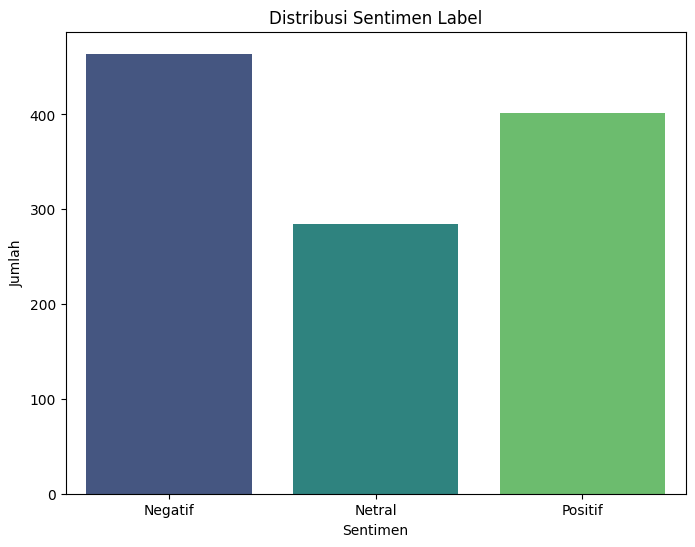

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate label counts
label_counts = df['label'].value_counts().sort_index()

# Map numerical labels to descriptive strings for better readability
label_map = {-1: 'Negatif', 0: 'Netral', 1: 'Positif'}
label_counts.index = label_counts.index.map(label_map)

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', hue=label_counts.index)
plt.title('Distribusi Sentimen Label')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

# preprocessing and cleaning data

In [32]:
# Lowercase semua huruf, menghapus tanda baca, dan menghapus angka, Hapus URL/link, Hapus mention (@user), Normalize hashtag, dan Hapus whitespace berlebih
import re
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Hapus URL/link
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Hapus mention (@user)
    text = re.sub(r'@\w+', '', text)

    # Normalize hashtag (hapus tanda # tapi tetap simpan kata)
    text = re.sub(r'#', '', text)

    # Hapus tanda baca dan angka
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = re.sub(r'\d+', '', text)      # Hapus angka

    # Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan preprocessing ke kolom 'tweet'
df['cleaned_tweet'] = df['isi_tweet'].apply(preprocess_text)
df.head()

,penulis,id_user,isi_tweet,label,cleaned_tweet
0,nangisadalahprivilege,@nangisadalahprivilege,info chatgpt prem dong ato perplexity prem yg murce #zonajajan #zonauang #mahasiswa,0,info chatgpt prem dong ato perplexity prem yg murce zonajajan zonauang mahasiswa
1,HasbiyalFurqon#IndonesiaGelap,@HasbiyalFurqon#IndonesiaGelap,"Saya sempet iseng-isengan aja, kalo anggaran proyek MBG yang 71T itu dipindahkan untuk subsidi seluruh mahasiswa di Indonesia (data nya saya minta ChatGPT jadi mungkin kurang akurat) rata-rata sebenernya bisa dapet sekitar 7 jutaan setahun.",1,saya sempet isengisengan aja kalo anggaran proyek mbg yang t itu dipindahkan untuk subsidi seluruh mahasiswa di indonesia data nya saya minta chatgpt jadi mungkin kurang akurat ratarata sebenernya bisa dapet sekitar jutaan setahun
2,halig,@halig,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua KLIK,0,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua klik
3,Hudya,@Hudya,Mahasiswa yang makin manja dengan ChatGPT bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan. So saya memutuskan bergabung menjadi youtuber edukasi pemrograman. Bedanya konten saya bener-bener akan ngomongin basicnya aja untuk level mahasiswa,-1,mahasiswa yang makin manja dengan chatgpt bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan so saya memutuskan bergabung menjadi youtuber edukasi pemrograman bedanya konten saya benerbener akan ngomongin basicnya aja untuk level mahasiswa
4,MinDos,@MinDos,"Iseng nanya chatgpt... Mahasiswa kesmas bisa magang dimana saja? Jawabannya: Untuk mencari referensi tempat magang bagi mahasiswa Kesehatan Masyarakat, Anda dapat: 1. **Kampus dan Dosen**: Kampus tempat Anda kuliah dan dosen di bidang Kesehatan Masyarakat bisa memberikan",0,iseng nanya chatgpt mahasiswa kesmas bisa magang dimana saja jawabannya untuk mencari referensi tempat magang bagi mahasiswa kesehatan masyarakat anda dapat kampus dan dosen kampus tempat anda kuliah dan dosen di bidang kesehatan masyarakat bisa memberikan


In [33]:
df[['cleaned_tweet','label']].head()

,cleaned_tweet,label
0,info chatgpt prem dong ato perplexity prem yg murce zonajajan zonauang mahasiswa,0
1,saya sempet isengisengan aja kalo anggaran proyek mbg yang t itu dipindahkan untuk subsidi seluruh mahasiswa di indonesia data nya saya minta chatgpt jadi mungkin kurang akurat ratarata sebenernya bisa dapet sekitar jutaan setahun,1
2,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sdg dua klik,0
3,mahasiswa yang makin manja dengan chatgpt bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan so saya memutuskan bergabung menjadi youtuber edukasi pemrograman bedanya konten saya benerbener akan ngomongin basicnya aja untuk level mahasiswa,-1
4,iseng nanya chatgpt mahasiswa kesmas bisa magang dimana saja jawabannya untuk mencari referensi tempat magang bagi mahasiswa kesehatan masyarakat anda dapat kampus dan dosen kampus tempat anda kuliah dan dosen di bidang kesehatan masyarakat bisa memberikan,0


## Normalization kata (Normalisasi Slang)

In [34]:
# Dictionary mapping slang ke bahasa baku
slang_map = {
    # ===== ORIGINAL KAMU (TETAP ADA) =====
    'yg': 'yang',
    'sgt': 'sangat',
    'kl': 'kalau',
    'klo': 'kalau',
    'dlm': 'dalam',
    'krn': 'karena',
    'tp': 'tapi',
    'gpp': 'gapapa',
    'u': 'anda',
    'gw': 'saya',
    'gue': 'saya',
    'guee': 'saya',
    'gua': 'saya',
    'lo': 'anda',
    'lu': 'anda',
    'elu': 'anda',
    'kuy': 'ayo',
    'tuh': 'itu',
    'kalo': 'kalau',
    'dg': 'dengan',
    'kek': 'seperti',
    'asik': 'asik',
    'ato': 'atau',
    'prem': 'premium',
    'murce': 'murah',
    'udh': 'sudah',
    'w': 'saya',
    'ga': 'tidak',
    'waduhh': 'waduh',

    # ===== TAMBAHAN 🔥 =====

    # negasi
    'gk': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'tdk': 'tidak',
    'tak': 'tidak',
    'gatau': 'tidak tahu',
    'gtw': 'tidak tahu',

    # intensitas
    'bgt': 'banget',
    'bgtt': 'banget',
    'bngt': 'banget',
    'bnget': 'banget',
    'bangett': 'banget',
    'bangettt': 'banget',

    # waktu
    'skrg': 'sekarang',
    'skrng': 'sekarang',
    'kmrn': 'kemarin',
    'tdi': 'tadi',
    'bsk': 'besok',

    # orang
    'km': 'kamu',
    'kmu': 'kamu',
    'org': 'orang',
    'org2': 'orang orang',

    # aktivitas
    'lg': 'lagi',
    'lgi': 'lagi',
    'sdg': 'sedang',

    # ekspresi
    'wkwk': 'tertawa',
    'wkwkwk': 'tertawa',
    'wkwkwkwk': 'tertawa',
    'hehe': 'tertawa',
    'haha': 'tertawa',

    # singkatan umum
    'dr': 'dari',
    'pd': 'pada',
    'sm': 'sama',
    'sma': 'sama',

    # pertanyaan
    'knp': 'kenapa',
    'ap': 'apa',

    # kampus / konteks
    'tgs': 'tugas',
    'uts': 'ujian tengah semester',
    'uas': 'ujian akhir semester',

    # chat / sosmed
    'dm': 'direct message',
    'pm': 'private message',
    'pls': 'tolong',
    'plis': 'tolong',

    # AI / dataset kamu 🔥
    'gpt': 'chatgpt',
    'chatgptnya': 'chatgpt',

    # typo umum
    'dpt': 'dapat',
    'dapet': 'dapat',

    # informal
    'nih': 'ini',
    'ni': 'ini',
    'gini': 'begini',
    'gitu': 'begitu',

    # tambahan penting
    'trs': 'terus',
    'trus': 'terus',
    'bs': 'bisa',
    'bsa': 'bisa',

    # jual beli (relevan banget dataset kamu 🔥)
    'murmer': 'murah meriah',
    'ori': 'original',
    'trusted': 'terpercaya'
}

def normalize_slang(text):
    """
    Tahapan 2: Normalisasi slang, leetspeak, dan repeated characters
    """
    words = text.split()
    normalized_words = []

    for word in words:
        # Normalisasi slang dari dictionary
        word = slang_map.get(word, word)
        word = re.sub(r'([a-z])\1{2,}', r'\1\1', word)

        # Leetspeak normalization: 4→a, 3→e, 1→i, 5→s, 0→o, 8→b, 9→g
        word = word.replace('4', 'a').replace('3', 'e').replace('1', 'i')
        word = word.replace('5', 's').replace('0', 'o').replace('8', 'b').replace('9', 'g')

        normalized_words.append(word)

    return ' '.join(normalized_words)


# Terapkan normalization ke cleaned_tweet
df['normalized_tweet'] = df['cleaned_tweet'].apply(normalize_slang)

In [35]:
df[['normalized_tweet','label']]

,normalized_tweet,label
0,info chatgpt premium dong atau perplexity premium yang murah zonajajan zonauang mahasiswa,0
1,saya sempet isengisengan aja kalau anggaran proyek mbg yang t itu dipindahkan untuk subsidi seluruh mahasiswa di indonesia data nya saya minta chatgpt jadi mungkin kurang akurat ratarata sebenernya bisa dapat sekitar jutaan setahun,1
2,chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sedang dua klik,0
3,mahasiswa yang makin manja dengan chatgpt bikin saya resah karena fundamental cara berpikir engineeringnya masih berantakan so saya memutuskan bergabung menjadi youtuber edukasi pemrograman bedanya konten saya benerbener akan ngomongin basicnya aja untuk level mahasiswa,-1
4,iseng nanya chatgpt mahasiswa kesmas bisa magang dimana saja jawabannya untuk mencari referensi tempat magang bagi mahasiswa kesehatan masyarakat anda dapat kampus dan dosen kampus tempat anda kuliah dan dosen di bidang kesehatan masyarakat bisa memberikan,0
5,banyak komplain bermunculan di antara para mahasiswa mereka memang tidak belajar makanya pakai chatgpt atau ai tapi kenapa bloon banget sih jawabannya dibagiin di grup terus yang pada nyontek waktu kuis gimana mereka juga kan pakai ai ini sih yang ngerjain,-1
6,ut menfess saya dosen tapi beneran tidak pernah kasih nilai jelek ke mahasiswa kecuali beneran ngaco sedangkan temen dosen saya yang lain segampang itu kasi nilai lgsg nuduh mahasiswa pake chatgpt jujur saya tidak sejalan sama mereka dan sering diomelin kenapa kasi nilai tinggi terus,1
7,wow berani bener dah mahasiswa saya pake chatgpt pas kuis lol,-1
8,guys ada yang mau tukeran tapi yang saya wawancara kriteria mahasiswa tingkat akhir yang sedang penelitian pernah menggunakan academic search engine contoh google scholar scopus dll dalam penelitian pernah menggunakan genai dalam penelitian contoh chatgpt gemini dll,0
9,tbf dari cuplikan yang ada gwordnya it was presentation session dari mahasiswa binus yang mengembangkan computer vision machine learning dan ai pathingterus tiba tiba dateng dia dan malah bagi bagi buku soal prompting chatgpt,-1


In [36]:
def tokenization(text):
    # Split berdasarkan whitespace
    tokens = text.split()
    return tokens

# Terapkan tokenization ke normalized_tweet
df['tokenized_tweet'] = df['normalized_tweet'].apply(tokenization)

print("\nContoh hasil tokenization:")
print("="*80)
for i in range(3):
    print(f"\n[{i}] TEXT: {df['normalized_tweet'].iloc[i]}")
    print(f"    TOKENS ({len(df['tokenized_tweet'].iloc[i])} kata): {df['tokenized_tweet'].iloc[i]}")
print("="*80)


# Statistik tokenization
print("STATISTIK TOKENIZATION:")
print("="*80)
df['token_count'] = df['tokenized_tweet'].apply(len)
print(f"\nJumlah token per tweet:")
print(f"  Mean   : {df['token_count'].mean():.2f}")
print(f"  Median : {df['token_count'].median():.2f}")
print(f"  Min    : {df['token_count'].min()}")
print(f"  Max    : {df['token_count'].max()}")

# Count frequency tokens
from collections import Counter
all_tokens = []
for tokens in df['tokenized_tweet']:
    all_tokens.extend(tokens)

token_freq = Counter(all_tokens)
print(f"\nTotal unique tokens: {len(token_freq)}")
print(f"\nTop 20 most frequent tokens:")
print("-"*80)
for token, freq in token_freq.most_common(20):
    print(f"  {token:20} : {freq:5} times")
print("="*80)


Contoh hasil tokenization:

[0] TEXT: info chatgpt premium dong atau perplexity premium yang murah zonajajan zonauang mahasiswa
    TOKENS (12 kata): ['info', 'chatgpt', 'premium', 'dong', 'atau', 'perplexity', 'premium', 'yang', 'murah', 'zonajajan', 'zonauang', 'mahasiswa']

[1] TEXT: saya sempet isengisengan aja kalau anggaran proyek mbg yang t itu dipindahkan untuk subsidi seluruh mahasiswa di indonesia data nya saya minta chatgpt jadi mungkin kurang akurat ratarata sebenernya bisa dapat sekitar jutaan setahun
    TOKENS (34 kata): ['saya', 'sempet', 'isengisengan', 'aja', 'kalau', 'anggaran', 'proyek', 'mbg', 'yang', 't', 'itu', 'dipindahkan', 'untuk', 'subsidi', 'seluruh', 'mahasiswa', 'di', 'indonesia', 'data', 'nya', 'saya', 'minta', 'chatgpt', 'jadi', 'mungkin', 'kurang', 'akurat', 'ratarata', 'sebenernya', 'bisa', 'dapat', 'sekitar', 'jutaan', 'setahun']

[2] TEXT: chatgpt tolong sebutkan judlu judul tguas stdui kasus mahasiswa itb syang berhubbungan dengan sedang dua klik
 

In [37]:
df[['tokenized_tweet','label']].head()

,tokenized_tweet,label
0,"[info, chatgpt, premium, dong, atau, perplexity, premium, yang, murah, zonajajan, zonauang, mahasiswa]",0
1,"[saya, sempet, isengisengan, aja, kalau, anggaran, proyek, mbg, yang, t, itu, dipindahkan, untuk, subsidi, seluruh, mahasiswa, di, indonesia, data, nya, saya, minta, chatgpt, jadi, mungkin, kurang, akurat, ratarata, sebenernya, bisa, dapat, sekitar, jutaan, setahun]",1
2,"[chatgpt, tolong, sebutkan, judlu, judul, tguas, stdui, kasus, mahasiswa, itb, syang, berhubbungan, dengan, sedang, dua, klik]",0
3,"[mahasiswa, yang, makin, manja, dengan, chatgpt, bikin, saya, resah, karena, fundamental, cara, berpikir, engineeringnya, masih, berantakan, so, saya, memutuskan, bergabung, menjadi, youtuber, edukasi, pemrograman, bedanya, konten, saya, benerbener, akan, ngomongin, basicnya, aja, untuk, level, mahasiswa]",-1
4,"[iseng, nanya, chatgpt, mahasiswa, kesmas, bisa, magang, dimana, saja, jawabannya, untuk, mencari, referensi, tempat, magang, bagi, mahasiswa, kesehatan, masyarakat, anda, dapat, kampus, dan, dosen, kampus, tempat, anda, kuliah, dan, dosen, di, bidang, kesehatan, masyarakat, bisa, memberikan]",0


## Stopword Removal

In [38]:
stopwords_id = {
    # Kata penghubung/konjungsi
    'dan', 'atau', 'serta', 'tetapi', 'tapi', 'namun', 'lalu', 'kemudian',

    # Preposisi
    'di', 'ke', 'dari', 'pada', 'oleh', 'untuk', 'dalam', 'atas', 'bawah',
    'dengan', 'tanpa', 'sebelum', 'sesudah', 'antara', 'diantara',

    # Kata ganti/Pronoun
    'yang', 'ini', 'itu', 'saya', 'kamu', 'dia', 'kami', 'kalian', 'mereka',
    'aku', 'kita', 'ia', 'beliau', 'siapa', 'apa',

    # Kata bantu
    'adalah', 'ada', 'ada', 'sudah', 'belum', 'sedang', 'akan', 'bisa', 'dapat',
    'boleh', 'harus', 'perlu', 'mesti', 'punya', 'tidak', 'tiada',

    # Kata kerja umum
    'ada', 'ada', 'lagi', 'terus', 'pun',

    # Partikel
    'lah', 'nih', 'nah', 'sih', 'deh', 'dong', 'kah', 'tah', 'pah',
    'aja', 'saja', 'juga', 'pula', 'malah', 'justru',

    # Angka/Jumlah
    'satu', 'dua', 'tiga', 'empat', 'lima', 'enam', 'tujuh', 'delapan', 'sembilan', 'sepuluh',

    # Lainnya
    'lebih','sangat', 'amat', 'begitu', 'begini', 'begitulah',
}

print(f"Total stopwords: {len(stopwords_id)}\n")

def remove_stopwords(tokens):
    # Filter: hapus stopwords dan kata dengan panjang <= 1 karakter
    filtered_tokens = [
        token for token in tokens
        if token not in stopwords_id and len(token) > 1
    ]

    return filtered_tokens


# Terapkan stopword removal ke tokenized_tweet
df['no_stopwords_tweet'] = df['tokenized_tweet'].apply(remove_stopwords)

print("\n" + "="*100)
print("PERBANDINGAN SEBELUM vs SESUDAH STOPWORD REMOVAL")
print("="*100)

for i in range(5):
    tokens_before = df['tokenized_tweet'].iloc[i]
    tokens_after = df['no_stopwords_tweet'].iloc[i]
    removed = set(tokens_before) - set(tokens_after)

    print(f"\n[{i}] TEXT: {df['normalized_tweet'].iloc[i]}\n")
    print(f"    BEFORE ({len(tokens_before)} tokens): {tokens_before}")
    print(f"    AFTER  ({len(tokens_after)} tokens): {tokens_after}")
    if removed:
        print(f"    REMOVED: {removed}")
    else:
        print(f"    REMOVED: (none)")

print("\n" + "="*100)


Total stopwords: 87


PERBANDINGAN SEBELUM vs SESUDAH STOPWORD REMOVAL

[0] TEXT: info chatgpt premium dong atau perplexity premium yang murah zonajajan zonauang mahasiswa

    BEFORE (12 tokens): ['info', 'chatgpt', 'premium', 'dong', 'atau', 'perplexity', 'premium', 'yang', 'murah', 'zonajajan', 'zonauang', 'mahasiswa']
    AFTER  (9 tokens): ['info', 'chatgpt', 'premium', 'perplexity', 'premium', 'murah', 'zonajajan', 'zonauang', 'mahasiswa']
    REMOVED: {'dong', 'yang', 'atau'}

[1] TEXT: saya sempet isengisengan aja kalau anggaran proyek mbg yang t itu dipindahkan untuk subsidi seluruh mahasiswa di indonesia data nya saya minta chatgpt jadi mungkin kurang akurat ratarata sebenernya bisa dapat sekitar jutaan setahun

    BEFORE (34 tokens): ['saya', 'sempet', 'isengisengan', 'aja', 'kalau', 'anggaran', 'proyek', 'mbg', 'yang', 't', 'itu', 'dipindahkan', 'untuk', 'subsidi', 'seluruh', 'mahasiswa', 'di', 'indonesia', 'data', 'nya', 'saya', 'minta', 'chatgpt', 'jadi', 'mungkin', 'kur

## Stemming

In [39]:
! pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.2 MB/s eta 0:00:00


In [40]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stemmer
stemmer = StemmerFactory().create_stemmer()

def stemming(tokens):
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens


# Terapkan stemming ke no_stopwords_tweet
df['stemmed_tweet'] = df['no_stopwords_tweet'].apply(stemming)

print("\n" + "="*100)
print("PERBANDINGAN SEBELUM vs SESUDAH STEMMING")
print("="*100)

for i in range(5):
    tokens_before = df['no_stopwords_tweet'].iloc[i]
    tokens_after = df['stemmed_tweet'].iloc[i]

    print(f"\n[{i}] BEFORE STEMMING ({len(tokens_before)} tokens):")
    print(f"    {tokens_before}")
    print(f"    AFTER STEMMING ({len(tokens_after)} tokens):")
    print(f"    {tokens_after}")

    # Show mapping
    print(f"    Mapping:")
    for before, after in zip(tokens_before, tokens_after):
        if before != after:
            print(f"      {before} → {after}")



PERBANDINGAN SEBELUM vs SESUDAH STEMMING

[0] BEFORE STEMMING (9 tokens):
    ['info', 'chatgpt', 'premium', 'perplexity', 'premium', 'murah', 'zonajajan', 'zonauang', 'mahasiswa']
    AFTER STEMMING (9 tokens):
    ['info', 'chatgpt', 'premium', 'perplexity', 'premium', 'murah', 'zonajajan', 'zonauang', 'mahasiswa']
    Mapping:

[1] BEFORE STEMMING (24 tokens):
    ['sempet', 'isengisengan', 'kalau', 'anggaran', 'proyek', 'mbg', 'dipindahkan', 'subsidi', 'seluruh', 'mahasiswa', 'indonesia', 'data', 'nya', 'minta', 'chatgpt', 'jadi', 'mungkin', 'kurang', 'akurat', 'ratarata', 'sebenernya', 'sekitar', 'jutaan', 'setahun']
    AFTER STEMMING (24 tokens):
    ['sempet', 'isengisengan', 'kalau', 'anggar', 'proyek', 'mbg', 'pindah', 'subsidi', 'seluruh', 'mahasiswa', 'indonesia', 'data', 'nya', 'minta', 'chatgpt', 'jadi', 'mungkin', 'kurang', 'akurat', 'ratarata', 'sebenernya', 'sekitar', 'juta', 'tahun']
    Mapping:
      anggaran → anggar
      dipindahkan → pindah
      jutaan → juta


In [41]:
df[['stemmed_tweet','label']].head()

,stemmed_tweet,label
0,"[info, chatgpt, premium, perplexity, premium, murah, zonajajan, zonauang, mahasiswa]",0
1,"[sempet, isengisengan, kalau, anggar, proyek, mbg, pindah, subsidi, seluruh, mahasiswa, indonesia, data, nya, minta, chatgpt, jadi, mungkin, kurang, akurat, ratarata, sebenernya, sekitar, juta, tahun]",1
2,"[chatgpt, tolong, sebut, judlu, judul, tguas, stdui, kasus, mahasiswa, itb, syang, berhubbungan, klik]",0
3,"[mahasiswa, makin, manja, chatgpt, bikin, resah, karena, fundamental, cara, pikir, engineeringnya, masih, beranta, so, putus, gabung, jadi, youtuber, edukasi, pemrograman, beda, konten, benerbener, ngomongin, basicnya, level, mahasiswa]",-1
4,"[iseng, nanya, chatgpt, mahasiswa, kesmas, magang, mana, jawab, cari, referensi, tempat, magang, bagi, mahasiswa, sehat, masyarakat, anda, kampus, dosen, kampus, tempat, anda, kuliah, dosen, bidang, sehat, masyarakat, beri]",0


## TF-IDF VECTORIZATION

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Step 1: Convert list of tokens kembali ke string
df['final_text'] = df['stemmed_tweet'].apply(lambda tokens: ' '.join(tokens))


# Step 2: Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,      # Max vocabulary size
    min_df=2,               # Min doc frequency
    max_df=0.8,             # Max doc frequency
    ngram_range=(1, 2),     # Unigrams dan bigrams
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'\w{1,}',
    stop_words=None,
    sublinear_tf=True       # Sublinear term frequency scaling
)

# Step 3: Fit and transform
print("Fitting TF-IDF vectorizer")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['final_text'])

# Step 4: Get vocabulary
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(feature_names)}")
print(f"Sample features (first 30):")
print(f"  {list(feature_names[:30])}\n")


# Get top words by tf-idf score
tfidf_array = tfidf_matrix.toarray()
feature_importance = np.asarray(tfidf_array.mean(axis=0)).ravel()
top_indices = feature_importance.argsort()[-30:][::-1]

print("\nTop 30 Most Important Features (by mean TF-IDF score):")
print("-"*100)
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank:2}. {feature_names[idx]:25} : {feature_importance[idx]:.6f}")

print("\n" + "="*100)


# ===== PER-SAMPLE TF-IDF ANALYSIS =====
print("\nANALISIS PER-SAMPLE TF-IDF SCORES:")
print("="*100)

for sample_idx in range(3):
    print(f"\n[SAMPLE {sample_idx}]")
    print(f"  Text: {df['final_text'].iloc[sample_idx]}")
    print(f"  Label: {df['label'].iloc[sample_idx]}")

    # Get non-zero TF-IDF scores for this sample
    sample_scores = tfidf_array[sample_idx]
    non_zero_indices = np.nonzero(sample_scores)[0]

    # Sort by score
    sorted_indices = non_zero_indices[np.argsort(-sample_scores[non_zero_indices])][:10]

    print(f"  Top 10 features:")
    for rank, idx in enumerate(sorted_indices, 1):
        print(f"    {feature_names[idx]:20} : {sample_scores[idx]:.6f}")

print("\n" + "="*100)

Fitting TF-IDF vectorizer
Vocabulary size: 3000
Sample features (first 30):
  ['abis', 'academic', 'ad', 'ada', 'adab', 'adaptasi', 'adik', 'adik tingkat', 'adl', 'aduh', 'ae', 'af', 'agak', 'agak aneh', 'agak kaget', 'agama', 'agar', 'agar terap', 'ah', 'ai', 'ai ai', 'ai bantu', 'ai buat', 'ai bukan', 'ai cara', 'ai chatgpt', 'ai copas', 'ai detector', 'ai dll', 'ai google']


Top 30 Most Important Features (by mean TF-IDF score):
----------------------------------------------------------------------------------------------------
   1. chat                      : 0.029988
   2. chat chatgpt              : 0.029093
   3. mahasiswa                 : 0.026338
   4. dosen                     : 0.026326
   5. pake                      : 0.025939
   6. uji                       : 0.025108
   7. semester                  : 0.024723
   8. akhir                     : 0.022409
   9. kalau                     : 0.022292
  10. pake chatgpt              : 0.021738
  11. sama                      

In [43]:
import pandas as pd

df_vector = pd.DataFrame({
    'vector': list(tfidf_matrix.toarray()),
    'label': df['label']
})

print(df_vector.head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     vector  \
0                                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [44]:
row = tfidf_matrix[1]

for idx, val in zip(row.indices, row.data):
    print(feature_names[idx], val)

mahasiswa 0.09640579465674821
sempet 0.22916364238558157
kalau 0.11110378818104735
proyek 0.277182496155774
pindah 0.277182496155774
seluruh 0.2495372428868151
indonesia 0.23336580640153518
data 0.18954911664729635
nya 0.16190386337833743
minta 0.17098872246184815
jadi 0.13175387970151714
mungkin 0.20572055313257628
kurang 0.2218919896178562
akurat 0.243389148073872
sebenernya 0.23336580640153518
sekitar 0.243389148073872
juta 0.265708679372095
tahun 0.1866990709239221
data nya 0.277182496155774
minta chatgpt 0.23806342610313613
chatgpt jadi 0.20800024043618884


## Tahap Modeling

## Random Forest

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [46]:
X = tfidf_matrix
y = df['label']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # penting untuk klasifikasi
)

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # jumlah tree
    max_depth=None,        # depth bebas
    random_state=42,
    n_jobs=-1              # pakai semua core CPU
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [49]:
y_pred = rf_model.predict(X_test)

In [50]:
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc:.4f}")

Akurasi: 0.5696


In [51]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          -1       0.62      0.65      0.63        93
           0       0.49      0.40      0.44        57
           1       0.55      0.60      0.57        80

    accuracy                           0.57       230
   macro avg       0.56      0.55      0.55       230
weighted avg       0.57      0.57      0.57       230



## SVM

In [52]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [53]:
from lightgbm import LGBMClassifier

In [54]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [55]:
print("=== SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

=== SVM ===
Akurasi: 0.5434782608695652
              precision    recall  f1-score   support

          -1       0.59      0.67      0.63        93
           0       0.50      0.37      0.42        57
           1       0.51      0.53      0.52        80

    accuracy                           0.54       230
   macro avg       0.53      0.52      0.52       230
weighted avg       0.54      0.54      0.54       230

[[62 10 21]
 [16 21 20]
 [27 11 42]]


## LightGBM

In [56]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1890
[LightGBM] [Info] Number of data points in the train set: 920, number of used features: 108
[LightGBM] [Info] Start training from score -0.908172
[LightGBM] [Info] Start training from score -1.399424
[LightGBM] [Info] Start training from score -1.049822
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [57]:
print("=== LightGBM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))

=== LightGBM ===
Akurasi: 0.4608695652173913
              precision    recall  f1-score   support

          -1       0.55      0.52      0.53        93
           0       0.33      0.30      0.31        57
           1       0.45      0.51      0.48        80

    accuracy                           0.46       230
   macro avg       0.44      0.44      0.44       230
weighted avg       0.46      0.46      0.46       230

[[48 20 25]
 [15 17 25]
 [25 14 41]]


In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

# EVALUATION FUNCTION

def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }


# COMPARE RESULTS

results = {
    'Random Forest': evaluate_model(y_test, y_pred),
    'SVM': evaluate_model(y_test, y_pred_svm),
    'LightGBM': evaluate_model(y_test, y_pred_lgbm)
}

df_results = pd.DataFrame(results).T

# PRINT RESULT

print("5️⃣ STEP 5: MODEL COMPARISON")
print("="*100)
print("\nTest Set Performance Summary:\n")
print(df_results)

# BEST MODEL

best_model_name = df_results['F1-Score'].idxmax()
best_f1 = df_results['F1-Score'].max()

print("\nBest Model:", best_model_name)
print(f"   F1-Score: {best_f1:.4f}")

5️⃣ STEP 5: MODEL COMPARISON

Test Set Performance Summary:

               Accuracy  Precision    Recall  F1-Score
Random Forest  0.569565   0.565898  0.569565  0.566292
SVM            0.543478   0.538679  0.543478  0.537614
LightGBM       0.460870   0.459875  0.460870  0.459274

Best Model: Random Forest
   F1-Score: 0.5663


## K-Fold Validation

In [60]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
import pandas as pd

# DEFINISI MODEL

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': LinearSVC(max_iter=10000),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42)
}

# K-FOLD SETUP

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# METRICS

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# CROSS VALIDATION

results = {}

for name, model in models.items():
    cv_result = cross_validate(
        model,
        X,   # TF-IDF matrix
        y,   # label
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        'Accuracy': cv_result['test_accuracy'].mean(),
        'Precision': cv_result['test_precision'].mean(),
        'Recall': cv_result['test_recall'].mean(),
        'F1-Score': cv_result['test_f1'].mean()
    }

# HASIL

df_cv_results = pd.DataFrame(results).T

print("K-FOLD (5) CROSS VALIDATION RESULTS")
print("="*100)
print(df_cv_results.round(4))

# BEST MODEL

best_model = df_cv_results['F1-Score'].idxmax()
best_score = df_cv_results['F1-Score'].max()

print("\nBest Model (K-Fold):", best_model)
print(f"   F1-Score: {best_score:.4f}")

K-FOLD (5) CROSS VALIDATION RESULTS
               Accuracy  Precision  Recall  F1-Score
Random Forest    0.5374     0.5285  0.5374    0.5245
SVM              0.5583     0.5483  0.5583    0.5500
LightGBM         0.4748     0.4674  0.4748    0.4683

Best Model (K-Fold): SVM
   F1-Score: 0.5500


## download model

In [61]:
import pickle

# simpan model
with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

print("Model SVM berhasil disimpan sebagai random_forest_model.pkl")

Model SVM berhasil disimpan sebagai random_forest_model.pkl


In [62]:
# simpan vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)

print("TF-IDF Vectorizer juga disimpan")

TF-IDF Vectorizer juga disimpan


In [63]:
# load model
with open('svm_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# load vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_vectorizer = pickle.load(file)

# test model

In [64]:
text_baru = ["mahasiswa makin manja dengan ai"]

# transform pakai vectorizer
X_new = loaded_vectorizer.transform(text_baru)

# prediksi
pred = loaded_model.predict(X_new)

print("Hasil prediksi:", pred)

Hasil prediksi: [-1]
